In [ ]:
import numpy as np
import pandas as pd
import sklearn
import matplotlib.pyplot as plt
import seaborn as sns

In [ ]:
df = pd.read_csv('https://raw.githubusercontent.com/anvarnarz/praktikum_datasets/main/housing_data_08-02-2021.csv')
df.head()

,location,district,rooms,size,level,max_levels,price
0,"город Ташкент, Юнусабадский район, Юнусабад 8-...",Юнусабадский,3,57,4,4,52000
1,"город Ташкент, Яккасарайский район, 1-й тупик ...",Яккасарайский,2,52,4,5,56000
2,"город Ташкент, Чиланзарский район, Чиланзар 2-...",Чиланзарский,2,42,4,4,37000
3,"город Ташкент, Чиланзарский район, Чиланзар 9-...",Чиланзарский,3,65,1,4,49500
4,"город Ташкент, Чиланзарский район, площадь Актепа",Чиланзарский,3,70,3,5,55000


In [ ]:
df.shape

(7565, 7)

In [ ]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 7565 entries, 0 to 7564
Data columns (total 7 columns):
 #   Column      Non-Null Count  Dtype 
---  ------      --------------  ----- 
 0   location    7565 non-null   object
 1   district    7565 non-null   object
 2   rooms       7565 non-null   int64 
 3   size        7565 non-null   object
 4   level       7565 non-null   int64 
 5   max_levels  7565 non-null   int64 
 6   price       7565 non-null   object
dtypes: int64(3), object(4)
memory usage: 413.8+ KB


In [ ]:
# Clean price column
df['price'] = df['price'].astype(str).str.replace(r'[^\d.]', '', regex=True)
df['price'] = pd.to_numeric(df['price'], errors='coerce')

# Clean size column
df['size'] = df['size'].astype(str).str.extract(r'(\d+\.?\d*)')
df['size'] = pd.to_numeric(df['size'], errors='coerce')

In [ ]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 7565 entries, 0 to 7564
Data columns (total 7 columns):
 #   Column      Non-Null Count  Dtype  
---  ------      --------------  -----  
 0   location    7565 non-null   object 
 1   district    7565 non-null   object 
 2   rooms       7565 non-null   int64  
 3   size        7565 non-null   float64
 4   level       7565 non-null   int64  
 5   max_levels  7565 non-null   int64  
 6   price       7466 non-null   float64
dtypes: float64(2), int64(3), object(2)
memory usage: 413.8+ KB


In [ ]:
df.describe()

,rooms,size,level,max_levels,price
count,7565.000000,7565.000000,7565.000000,7565.000000,7.466000e+03
mean,2.625644,113.254149,3.699273,6.038202,7.133421e+04
std,1.085201,1491.214068,2.237275,2.613271,6.405237e+05
min,1.000000,1.000000,1.000000,1.000000,2.000000e+00
25%,2.000000,50.000000,2.000000,4.000000,3.500000e+04
50%,3.000000,66.000000,3.000000,5.000000,4.650000e+04
75%,3.000000,86.000000,5.000000,9.000000,6.700000e+04
max,10.000000,70000.000000,19.000000,25.000000,5.200000e+07


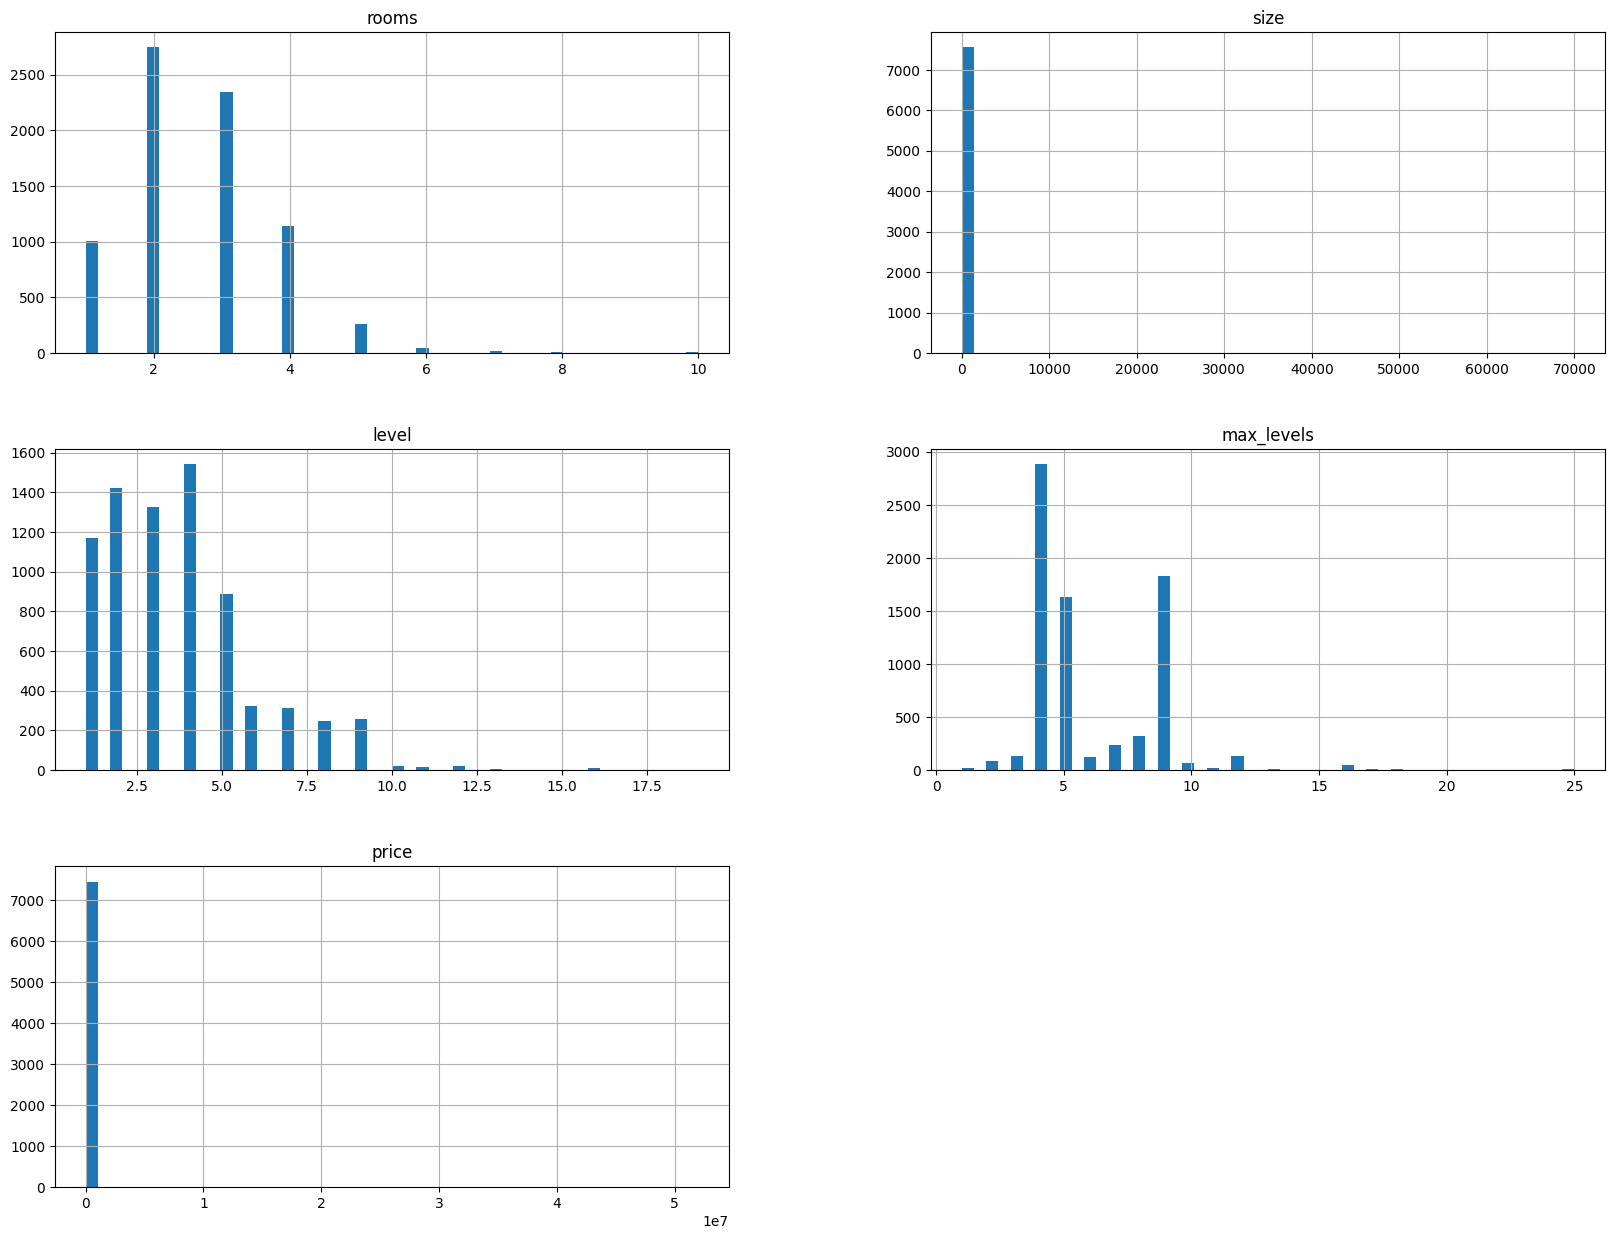

In [ ]:
%matplotlib inline
df.hist(bins=50, figsize=(20,15))
plt.show()

In [ ]:
from sklearn.model_selection import train_test_split
train_set, test_set = train_test_split(df, test_size=0.2, random_state=50)

In [ ]:
test_set

,location,district,rooms,size,level,max_levels,price
1878,"город Ташкент, Учтепинский район, Чиланзар 24-...",Учтепинский,2,50.0,4,4,33000.0
6859,"город Ташкент, Яшнободский район, Махтумкули",Яшнободский,4,111.0,5,7,NaN
6903,"город Ташкент, Чиланзарский район, Чиланзар-4",Чиланзарский,2,60.0,3,5,35500.0
1712,"город Ташкент, Яшнободский район, Тузель 1-й к...",Яшнободский,4,80.0,2,5,47000.0
2013,"город Ташкент, Чиланзарский район, Чиланзар кв...",Чиланзарский,3,97.0,7,8,67997.0
...,...,...,...,...,...,...,...
7348,"город Ташкент, Чиланзарский район, Чиланзар 2-...",Чиланзарский,2,56.0,2,9,35000.0
3666,"город Ташкент, Шайхантахурский район, Богкуча",Шайхантахурский,2,58.0,6,9,44500.0
4066,"город Ташкент, Учтепинский район, Чиланзар 15-...",Учтепинский,2,42.0,4,5,28500.0
6577,"город Ташкент, Учтепинский район, Фазылтепа",Учтепинский,2,90.0,2,5,65000.0


In [ ]:
train_set

,location,district,rooms,size,level,max_levels,price
6180,"город Ташкент, Мирзо-Улугбекский район, Карасу...",Мирзо-Улугбекский,4,92.0,3,5,63000.0
984,"город Ташкент, Мирабадский район, ул.Нукус",Мирабадский,3,100.0,5,6,115000.0
6426,"город Ташкент, Учтепинский район, Чиланзар 11-...",Учтепинский,3,65.0,4,4,44000.0
2407,"город Ташкент, Мирзо-Улугбекский район, Буюк И...",Мирзо-Улугбекский,3,70.0,9,9,45000.0
1331,"город Ташкент, Учтепинский район, Чиланзар 14-...",Учтепинский,4,138.0,2,4,95000.0
...,...,...,...,...,...,...,...
7457,"город Ташкент, Яккасарайский район, Абдуллы Ка...",Яккасарайский,3,84.0,11,16,52000.0
6253,"город Ташкент, Чиланзарский район, Чиланзар 5-...",Чиланзарский,3,110.0,3,9,78000.0
1931,"город Ташкент, Мирзо-Улугбекский район, Мирзо-...",Мирзо-Улугбекский,3,72.0,4,4,41000.0
5600,"город Ташкент, Чиланзарский район, Чиланзар-Ц",Чиланзарский,2,50.0,4,4,33500.0


In [ ]:
from sklearn.model_selection import StratifiedShuffleSplit

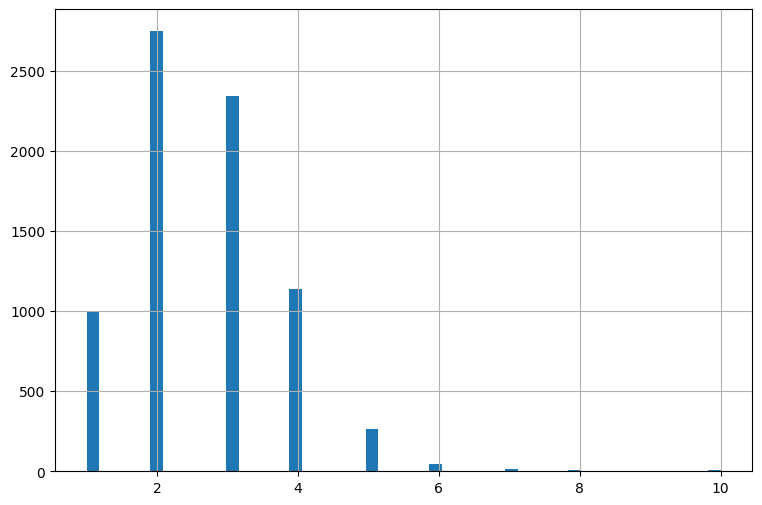

In [ ]:
%matplotlib inline
df['rooms'].hist(bins=50, figsize=(9,6))
plt.show()

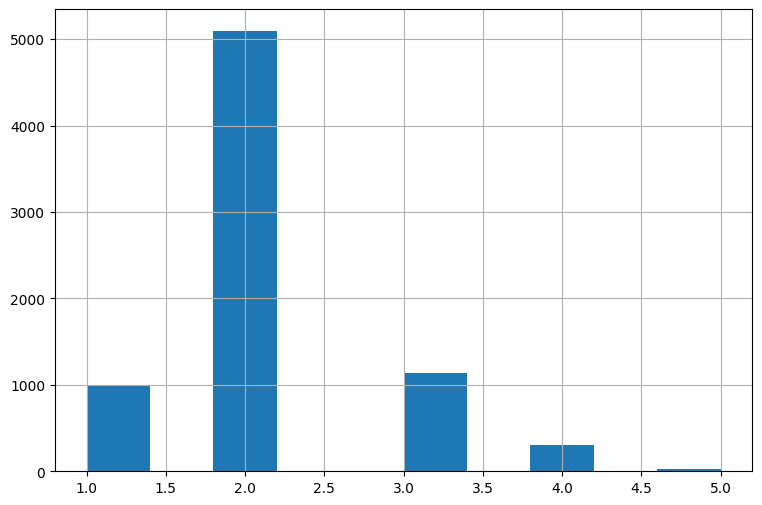

In [ ]:
df['rooms_cat'] = pd.cut(df['rooms'], bins=[0., 1.5, 3.0, 4.5, 6.0, np.inf], labels=[1,2,3,4,5])
df['rooms_cat'].hist(figsize=(9,6))
plt.show()

In [ ]:
df.sample(5)

,location,district,rooms,size,level,max_levels,price,rooms_cat
259,"город Ташкент, Чиланзарский район, Чиланзар 17...",Чиланзарский,2,50.0,1,4,34000.0,2
4626,"город Ташкент, Сергелийский район, Куйлюк 6-й ...",Сергелийский,4,104.0,2,9,68000.0,3
5251,"город Ташкент, Чиланзарский район, Мукими",Чиланзарский,3,68.0,3,4,48900.0,2
5827,"город Ташкент, Мирабадский район, Янги Миробод",Мирабадский,3,65.0,4,4,57000.0,2
6211,"город Ташкент, Чиланзарский район, Чиланзар 19...",Чиланзарский,5,117.0,1,4,95000.0,4


In [ ]:
from sklearn.model_selection import StratifiedShuffleSplit
stratified_split = StratifiedShuffleSplit(n_splits=1, test_size=0.2, random_state=42)

for train_index, test_index in stratified_split.split(df, df['rooms_cat']):
  strat_train_set = df.loc[train_index]
  strat_test_set = df.loc[test_index]

In [ ]:
strat_train_set

,location,district,rooms,size,level,max_levels,price,rooms_cat
1190,"город Ташкент, Учтепинский район, Гулистон",Учтепинский,2,60.0,1,4,56000.0,2
325,"город Ташкент, Чиланзарский район, Чиланзар кв...",Чиланзарский,3,68.0,3,4,39000.0,2
2231,"город Ташкент, Яккасарайский район, Кичик Бешагач",Яккасарайский,2,48.0,1,4,37500.0,2
4471,"город Ташкент, Мирзо-Улугбекский район, Буз 2",Мирзо-Улугбекский,2,60.0,3,5,38000.0,2
6404,"город Ташкент, Учтепинский район, Чиланзар 30-...",Учтепинский,3,90.0,1,12,51000.0,2
...,...,...,...,...,...,...,...,...
744,"город Ташкент, Яшнободский район, 1-й проезд А...",Яшнободский,3,67.0,4,4,39000.0,2
6330,"город Ташкент, Чиланзарский район, Чиланзар 7-...",Чиланзарский,4,90.0,7,9,95000.0,3
3597,"город Ташкент, Учтепинский район, Чиланзар 24-...",Учтепинский,3,72.0,4,9,43500.0,2
6199,"город Ташкент, Учтепинский район, Чиланзар 21-...",Учтепинский,1,33.0,2,4,28000.0,1


In [ ]:
strat_test_set

,location,district,rooms,size,level,max_levels,price,rooms_cat
517,"город Ташкент, Юнусабадский район, Юнусабад 4-...",Юнусабадский,2,68.0,9,9,36500.0,2
4541,"город Ташкент, Сергелийский район, 1-й проезд ...",Сергелийский,2,70.0,4,9,29500.0,2
3045,"город Ташкент, Яшнободский район, Ташсельмаш",Яшнободский,2,48.0,2,3,31000.0,2
6902,"город Ташкент, Чиланзарский район, Чиланзар",Чиланзарский,2,60.0,3,5,33500.0,2
1705,"город Ташкент, Мирзо-Улугбекский район, Ул Мир...",Мирзо-Улугбекский,1,30.0,3,4,25000.0,1
...,...,...,...,...,...,...,...,...
2843,"город Ташкент, Мирабадский район, 3-й проезд А...",Мирабадский,3,115.0,8,9,87000.0,2
3500,"город Ташкент, Шайхантахурский район, Ибн Сино-2",Шайхантахурский,1,42.0,8,9,21000.0,1
1110,"город Ташкент, Мирзо-Улугбекский район, ПАРКЕН...",Мирзо-Улугбекский,4,106.0,6,8,115000.0,3
1111,"город Ташкент, Мирзо-Улугбекский район, Олой",Мирзо-Улугбекский,2,60.0,2,5,38200.0,2


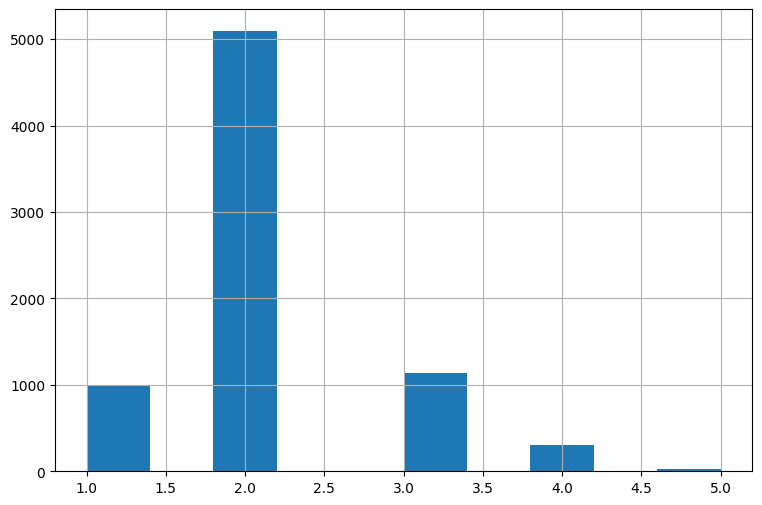

In [ ]:
df['rooms_cat'].hist(figsize=(9,6))
plt.show()

In [ ]:
for sets in [strat_train_set, strat_test_set]:
  sets.drop('rooms_cat', axis=1, inplace=True)

In [ ]:
housing = strat_train_set.copy()
housing.head()

,location,district,rooms,size,level,max_levels,price
1190,"город Ташкент, Учтепинский район, Гулистон",Учтепинский,2,60.0,1,4,56000.0
325,"город Ташкент, Чиланзарский район, Чиланзар кв...",Чиланзарский,3,68.0,3,4,39000.0
2231,"город Ташкент, Яккасарайский район, Кичик Бешагач",Яккасарайский,2,48.0,1,4,37500.0
4471,"город Ташкент, Мирзо-Улугбекский район, Буз 2",Мирзо-Улугбекский,2,60.0,3,5,38000.0
6404,"город Ташкент, Учтепинский район, Чиланзар 30-...",Учтепинский,3,90.0,1,12,51000.0


In [ ]:
cols = ['rooms','size','level','max_levels','price']
housing[cols].corrwith(housing['price']).sort_values(ascending=False)

,0
price,1.000000
rooms,0.054197
max_levels,0.007667
size,0.000770
level,-0.007353


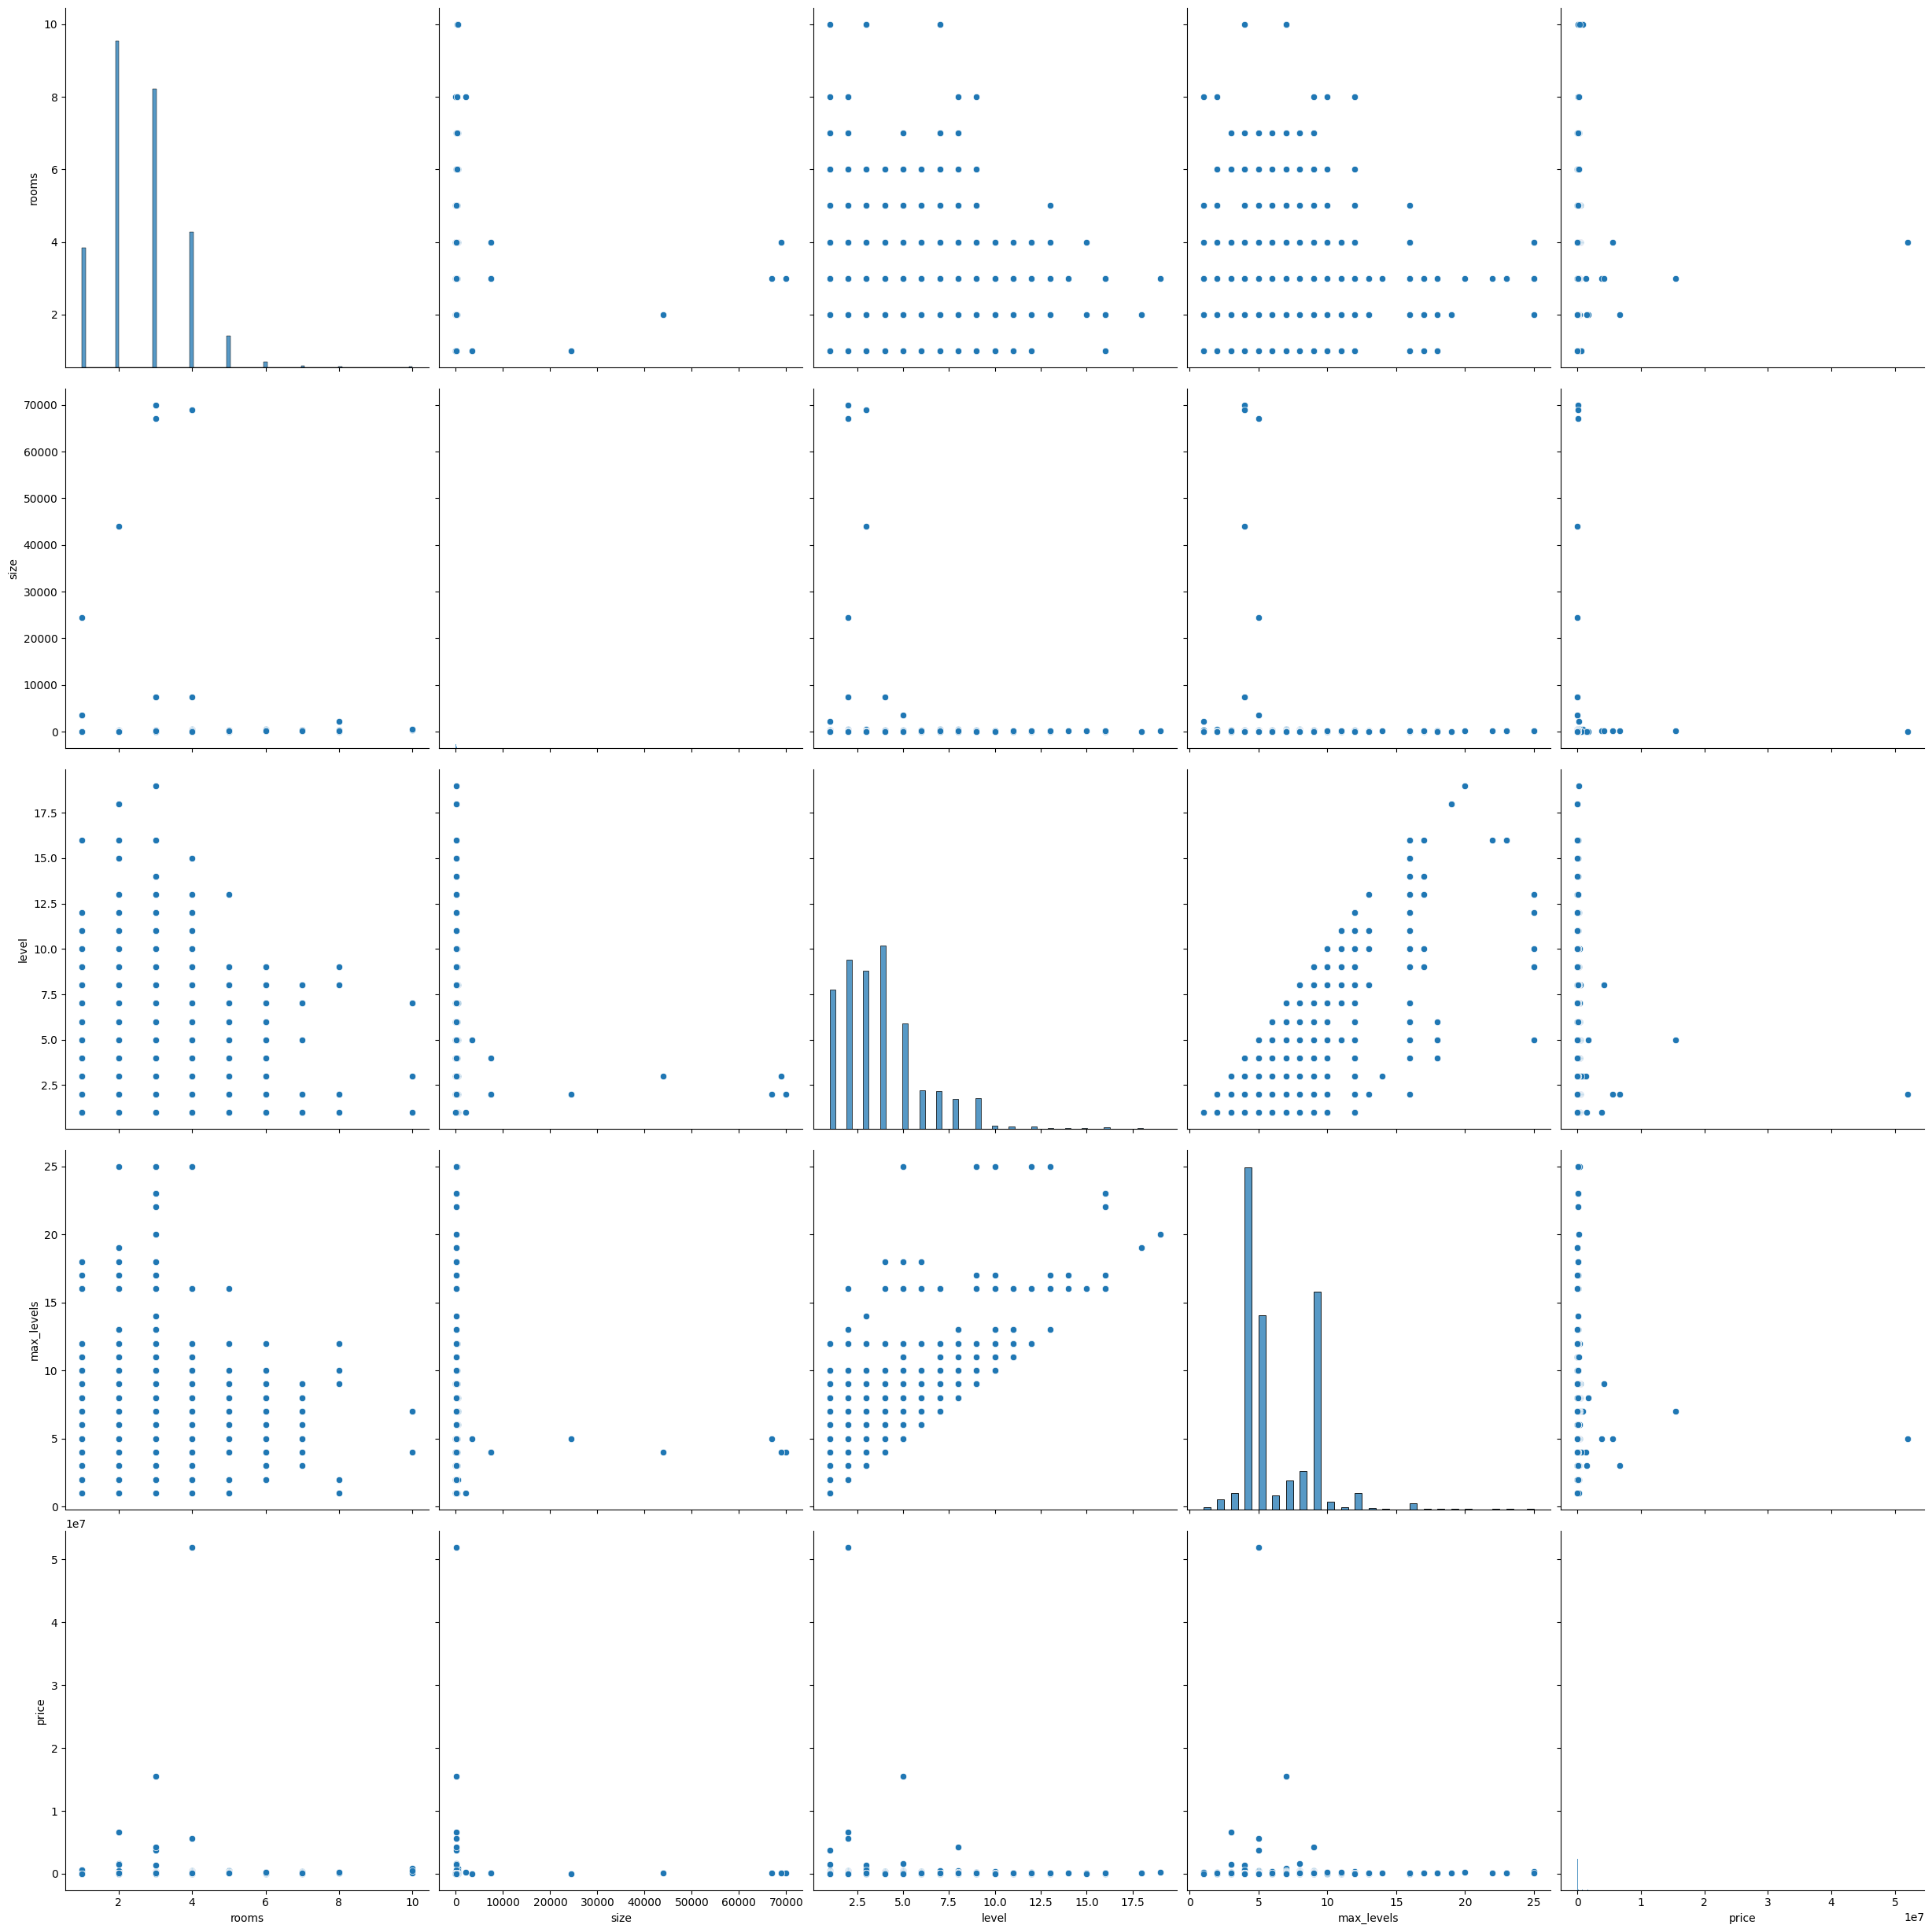

In [ ]:
sns.pairplot(df[cols], height=5)
plt.show()

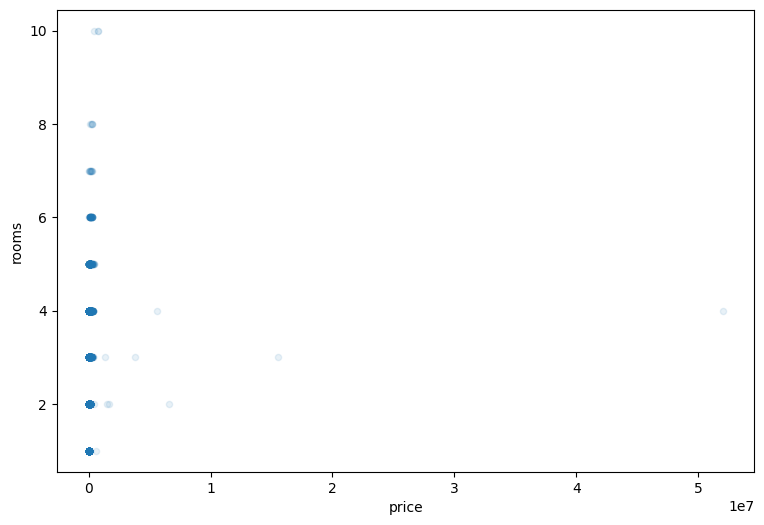

In [ ]:
housing.plot(kind='scatter', x='price', y='rooms', alpha=0.1, figsize=(9,6))
plt.show()

In [ ]:
housing.isnull().sum()

,0
location,0
district,0
rooms,0
size,0
level,0
max_levels,0
price,77


In [ ]:
price_median = housing['price'].median()
size_median = housing['size'].median()

In [ ]:
housing['price'].fillna(price_median)
housing['size'].fillna(size_median)

,size
1190,60.0
325,68.0
2231,48.0
4471,60.0
6404,90.0
...,...
744,67.0
6330,90.0
3597,72.0
6199,33.0


# SIMPLE IMPUTER

In [ ]:
from sklearn.impute import SimpleImputer

In [ ]:
imputer = SimpleImputer(strategy='median')

In [ ]:
imputer.fit(housing)

ValueError: Cannot use median strategy with non-numeric data:
could not convert string to float: 'город Ташкент, Учтепинский район, Гулистон'

In [ ]:
housing_num = housing.drop(['location', 'district'], axis=1)

In [ ]:
imputer.fit(housing_num)

SimpleImputer(strategy='median')

In [ ]:
imputer.statistics_

array([3.00e+00, 6.70e+01, 3.00e+00, 5.00e+00, 4.65e+04])

In [ ]:
X = imputer.transform(housing_num)
X

array([[2.00e+00, 6.00e+01, 1.00e+00, 4.00e+00, 5.60e+04],
       [3.00e+00, 6.80e+01, 3.00e+00, 4.00e+00, 3.90e+04],
       [2.00e+00, 4.80e+01, 1.00e+00, 4.00e+00, 3.75e+04],
       ...,
       [3.00e+00, 7.20e+01, 4.00e+00, 9.00e+00, 4.35e+04],
       [1.00e+00, 3.30e+01, 2.00e+00, 4.00e+00, 2.80e+04],
       [3.00e+00, 7.50e+01, 2.00e+00, 9.00e+00, 7.40e+04]])

In [ ]:
X = imputer.fit_transform(housing_num)
X

array([[2.00e+00, 6.00e+01, 1.00e+00, 4.00e+00, 5.60e+04],
       [3.00e+00, 6.80e+01, 3.00e+00, 4.00e+00, 3.90e+04],
       [2.00e+00, 4.80e+01, 1.00e+00, 4.00e+00, 3.75e+04],
       ...,
       [3.00e+00, 7.20e+01, 4.00e+00, 9.00e+00, 4.35e+04],
       [1.00e+00, 3.30e+01, 2.00e+00, 4.00e+00, 2.80e+04],
       [3.00e+00, 7.50e+01, 2.00e+00, 9.00e+00, 7.40e+04]])

In [ ]:
housing_tr = pd.DataFrame(X, columns=housing_num.columns, index=housing_num.index)
housing_tr.head()

,rooms,size,level,max_levels,price
1190,2.0,60.0,1.0,4.0,56000.0
325,3.0,68.0,3.0,4.0,39000.0
2231,2.0,48.0,1.0,4.0,37500.0
4471,2.0,60.0,3.0,5.0,38000.0
6404,3.0,90.0,1.0,12.0,51000.0


In [ ]:
housing_tr.info()

<class 'pandas.core.frame.DataFrame'>
Index: 6052 entries, 1190 to 2474
Data columns (total 5 columns):
 #   Column      Non-Null Count  Dtype  
---  ------      --------------  -----  
 0   rooms       6052 non-null   float64
 1   size        6052 non-null   float64
 2   level       6052 non-null   float64
 3   max_levels  6052 non-null   float64
 4   price       6052 non-null   float64
dtypes: float64(5)
memory usage: 283.7 KB


# ORDINAL ENCODER

In [ ]:
from sklearn.preprocessing import OrdinalEncoder

ordinal_encoder = OrdinalEncoder()

In [ ]:
housing_cat = housing[['location']]
housing_cat.value_counts()

,count
location,
"город Ташкент, Чиланзарский район, Чиланзар",93
"город Ташкент, Яккасарайский район, Кушбеги",87
"город Ташкент, Мирзо-Улугбекский район, Буюк Ипак Йули",69
"город Ташкент, Учтепинский район, Чиланзар 24-й квартал",67
"город Ташкент, Яккасарайский район, Бабура",64
...,...
"город Ташкент, Мирабадский район, 2-й проезд Куйлюк",1
"город Ташкент, Яшнободский район, Циолковского",1
"город Ташкент, Мирабадский район, Айбек метро 3/6/9 без ремонт дом Китай стена",1


In [ ]:
housing_encoded = ordinal_encoder.fit_transform(housing_cat)
housing_encoded

array([[ 595.],
       [ 800.],
       [1153.],
       ...,
       [ 632.],
       [ 629.],
       [  28.]])

In [ ]:
housing_cat1 = housing[['district']]
housing_cat1.value_counts()

,count
district,
Чиланзарский,1307
Мирзо-Улугбекский,1118
Учтепинский,714
Юнусабадский,702
Мирабадский,623
Яккасарайский,543
Яшнободский,381
Шайхантахурский,310
Олмазорский,215


In [ ]:
housing_encoded1 = ordinal_encoder.fit_transform(housing_cat1)
housing_encoded1

array([[5.],
       [6.],
       [9.],
       ...,
       [5.],
       [5.],
       [1.]])

# One Hot Encoder

In [ ]:
from sklearn.preprocessing import OneHotEncoder

cat_encoder = OneHotEncoder()

housing_cat_1hot = cat_encoder.fit_transform(housing_cat)
housing_cat_1hot.toarray()

array([[0., 0., 0., ..., 0., 0., 0.],
       [0., 0., 0., ..., 0., 0., 0.],
       [0., 0., 0., ..., 0., 0., 0.],
       ...,
       [0., 0., 0., ..., 0., 0., 0.],
       [0., 0., 0., ..., 0., 0., 0.],
       [0., 0., 0., ..., 0., 0., 0.]])

In [ ]:
housing_cat.value_counts()

,count
location,
"город Ташкент, Чиланзарский район, Чиланзар",93
"город Ташкент, Яккасарайский район, Кушбеги",87
"город Ташкент, Мирзо-Улугбекский район, Буюк Ипак Йули",69
"город Ташкент, Учтепинский район, Чиланзар 24-й квартал",67
"город Ташкент, Яккасарайский район, Бабура",64
...,...
"город Ташкент, Мирабадский район, 2-й проезд Куйлюк",1
"город Ташкент, Яшнободский район, Циолковского",1
"город Ташкент, Мирабадский район, Айбек метро 3/6/9 без ремонт дом Китай стена",1


In [ ]:
housing_cat

,location
1190,"город Ташкент, Учтепинский район, Гулистон"
325,"город Ташкент, Чиланзарский район, Чиланзар кв..."
2231,"город Ташкент, Яккасарайский район, Кичик Бешагач"
4471,"город Ташкент, Мирзо-Улугбекский район, Буз 2"
6404,"город Ташкент, Учтепинский район, Чиланзар 30-..."
...,...
744,"город Ташкент, Яшнободский район, 1-й проезд А..."
6330,"город Ташкент, Чиланзарский район, Чиланзар 7-..."
3597,"город Ташкент, Учтепинский район, Чиланзар 24-..."
6199,"город Ташкент, Учтепинский район, Чиланзар 21-..."


In [ ]:
housing_onehot = pd.get_dummies(housing_cat['location'])
housing_onehot

,"город Ташкент, Бектемирский район, Билола Нозима","город Ташкент, Бектемирский район, Конечная остановка","город Ташкент, Бектемирский район, Массив Водник","город Ташкент, Бектемирский район, Сувсоз-1 (Водник)","город Ташкент, Бектемирский район, Сувсоз-2 (Водник-2)","город Ташкент, Мирабадский район","город Ташкент, Мирабадский район, 1-й Нукусский проезд","город Ташкент, Мирабадский район, 1-й проезд Абдурауфа Фитрата","город Ташкент, Мирабадский район, 1-й проезд Инокобод","город Ташкент, Мирабадский район, 1-й проезд Катта Миробод",...,"город Ташкент, Яшнободский район, Японское посольство","город Ташкент, Яшнободский район, Яшнобод","город Ташкент, Яшнободский район, гузал махалля","город Ташкент, Яшнободский район, жилой комплекс Green Park","город Ташкент, Яшнободский район, жилой комплекс Parkent Village массив Мавлоно Риёзи","город Ташкент, Яшнободский район, жилой комплекс Обод Макон","город Ташкент, Яшнободский район, жилой комплекс У.М. Шахидов 58-й городок","город Ташкент, Яшнободский район, жилой комплекс Эльбек Яшнободский район","город Ташкент, Яшнободский район, пр-т Мирзо Улугбека","город Ташкент, Яшнободский район, тупик Мавляна Риёзи"
1190,False,False,False,False,False,False,False,False,False,False,...,False,False,False,False,False,False,False,False,False,False
325,False,False,False,False,False,False,False,False,False,False,...,False,False,False,False,False,False,False,False,False,False
2231,False,False,False,False,False,False,False,False,False,False,...,False,False,False,False,False,False,False,False,False,False
4471,False,False,False,False,False,False,False,False,False,False,...,False,False,False,False,False,False,False,False,False,False
6404,False,False,False,False,False,False,False,False,False,False,...,False,False,False,False,False,False,False,False,False,False
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
744,False,False,False,False,False,False,False,False,False,False,...,False,False,False,False,False,False,False,False,False,False
6330,False,False,False,False,False,False,False,False,False,False,...,False,False,False,False,False,False,False,False,False,False
3597,False,False,False,False,False,False,False,False,False,False,...,False,False,False,False,False,False,False,False,False,False
6199,False,False,False,False,False,False,False,False,False,False,...,False,False,False,False,False,False,False,False,False,False


# Min Max Scaler

In [ ]:
housing.describe()

,rooms,size,level,max_levels,price
count,6052.000000,6052.000000,6052.000000,6052.000000,5.975000e+03
mean,2.625909,122.026657,3.703569,6.049405,7.383730e+04
std,1.081924,1664.359849,2.237885,2.625852,7.135473e+05
min,1.000000,1.000000,1.000000,1.000000,2.000000e+00
25%,2.000000,50.000000,2.000000,4.000000,3.500000e+04
50%,3.000000,67.000000,3.000000,5.000000,4.650000e+04
75%,3.000000,86.000000,5.000000,9.000000,6.700000e+04
max,10.000000,70000.000000,19.000000,25.000000,5.200000e+07


In [ ]:
from sklearn.preprocessing import MinMaxScaler

In [ ]:
min_max_scaler = MinMaxScaler()

min_max_scaler.fit_transform(housing_num)

array([[0.11111111, 0.00084287, 0.        , 0.125     , 0.00107688],
       [0.22222222, 0.00095716, 0.11111111, 0.125     , 0.00074996],
       [0.11111111, 0.00067144, 0.        , 0.125     , 0.00072112],
       ...,
       [0.22222222, 0.0010143 , 0.16666667, 0.33333333, 0.0008365 ],
       [0.        , 0.00045715, 0.05555556, 0.125     , 0.00053842],
       [0.22222222, 0.00105716, 0.05555556, 0.33333333, 0.00142304]])

In [ ]:
housing_num

,rooms,size,level,max_levels,price
1190,2,60.0,1,4,56000.0
325,3,68.0,3,4,39000.0
2231,2,48.0,1,4,37500.0
4471,2,60.0,3,5,38000.0
6404,3,90.0,1,12,51000.0
...,...,...,...,...,...
744,3,67.0,4,4,39000.0
6330,4,90.0,7,9,95000.0
3597,3,72.0,4,9,43500.0
6199,1,33.0,2,4,28000.0


In [ ]:
from sklearn.preprocessing import StandardScaler

standard_scaler = StandardScaler()
standard_scaler.fit_transform(housing_num)

array([[-5.78562295e-01, -3.72706554e-02, -1.20819072e+00,
        -7.80537079e-01, -2.50001526e-02],
       [ 3.45793304e-01, -3.24636054e-02, -3.14416092e-01,
        -7.80537079e-01, -4.88267770e-02],
       [-5.78562295e-01, -4.44812304e-02, -1.20819072e+00,
        -7.80537079e-01, -5.09291262e-02],
       ...,
       [ 3.45793304e-01, -3.00600804e-02,  1.32471223e-01,
         1.12376446e+00, -4.25197294e-02],
       [-1.50291789e+00, -5.34944492e-02, -7.61303406e-01,
        -7.80537079e-01, -6.42440046e-02],
       [ 3.45793304e-01, -2.82574367e-02, -7.61303406e-01,
         1.12376446e+00,  2.28037978e-04]])

In [ ]:
housing = df.drop('price', axis=1)
housing_labels = df['price'].copy()

In [ ]:
housing_num = housing.drop(['location', 'district'], axis=1)

In [ ]:
from sklearn.preprocessing import OneHotEncoder, StandardScaler
from sklearn.impute import SimpleImputer
from sklearn.pipeline import Pipeline

num_pipeline = Pipeline([
    ('imputer', SimpleImputer(strategy='median')),
    ('stad', StandardScaler())
])

num_pipeline.fit_transform(housing_num)

array([[ 0.34498717, -0.03772622,  0.13442554, -0.77999447, -0.16030667],
       [-0.57656225, -0.04107941,  0.13442554, -0.397307  , -0.16030667],
       [-0.57656225, -0.0477858 ,  0.13442554, -0.77999447, -0.16030667],
       ...,
       [-0.57656225, -0.03303175, -0.3125763 ,  1.13344291, -0.16030667],
       [-1.49811166, -0.06388113, -1.20657998, -0.77999447, -1.63027022],
       [-1.49811166, -0.05583347, -0.75957814, -0.77999447, -1.63027022]])

In [ ]:
from sklearn.compose import ColumnTransformer

num_attrib = list(housing_num)
cat_attrib1 = ['district']
cat_attrib2 = ['location']

full_pipeline = ColumnTransformer([
    ('num', num_pipeline, num_attrib),
    ('cat1', OneHotEncoder(sparse_output=False), cat_attrib1),
    ('cat2', OneHotEncoder(sparse_output=False), cat_attrib2)
])

In [ ]:
housing_prepared = full_pipeline.fit_transform(housing)

In [ ]:
housing_prepared

array([[ 0.34498717, -0.03772622,  0.13442554, ...,  0.        ,
         0.        ,  0.        ],
       [-0.57656225, -0.04107941,  0.13442554, ...,  0.        ,
         0.        ,  0.        ],
       [-0.57656225, -0.0477858 ,  0.13442554, ...,  0.        ,
         0.        ,  0.        ],
       ...,
       [-0.57656225, -0.03303175, -0.3125763 , ...,  0.        ,
         0.        ,  0.        ],
       [-1.49811166, -0.06388113, -1.20657998, ...,  0.        ,
         0.        ,  0.        ],
       [-1.49811166, -0.05583347, -0.75957814, ...,  0.        ,
         0.        ,  0.        ]])

In [ ]:
housing_prepared[0:5, :]

array([[ 0.34498717, -0.03772622,  0.13442554, ...,  0.        ,
         0.        ,  0.        ],
       [-0.57656225, -0.04107941,  0.13442554, ...,  0.        ,
         0.        ,  0.        ],
       [-0.57656225, -0.0477858 ,  0.13442554, ...,  0.        ,
         0.        ,  0.        ],
       [ 0.34498717, -0.03236111, -1.20657998, ...,  0.        ,
         0.        ,  0.        ],
       [ 0.34498717, -0.02900791, -0.3125763 , ...,  0.        ,
         0.        ,  0.        ]])

#Machine Learning


In [ ]:
df = pd.read_csv('https://raw.githubusercontent.com/anvarnarz/praktikum_datasets/main/housing_data_08-02-2021.csv')
df

,location,district,rooms,size,level,max_levels,price
0,"город Ташкент, Юнусабадский район, Юнусабад 8-...",Юнусабадский,3,57,4,4,52000
1,"город Ташкент, Яккасарайский район, 1-й тупик ...",Яккасарайский,2,52,4,5,56000
2,"город Ташкент, Чиланзарский район, Чиланзар 2-...",Чиланзарский,2,42,4,4,37000
3,"город Ташкент, Чиланзарский район, Чиланзар 9-...",Чиланзарский,3,65,1,4,49500
4,"город Ташкент, Чиланзарский район, площадь Актепа",Чиланзарский,3,70,3,5,55000
...,...,...,...,...,...,...,...
7560,"город Ташкент, Яшнободский район, Городок Авиа...",Яшнободский,1,38,5,5,24500
7561,"город Ташкент, Яшнободский район, 1-й проезд А...",Яшнободский,2,49,1,4,32000
7562,"город Ташкент, Шайхантахурский район, Зульфиях...",Шайхантахурский,2,64,3,9,40000
7563,"город Ташкент, Мирзо-Улугбекский район, Буюк И...",Мирзо-Улугбекский,1,18,1,4,11000


In [ ]:
# Clean price column
df['price'] = df['price'].astype(str).str.replace(r'[^\d.]', '', regex=True)
df['price'] = pd.to_numeric(df['price'], errors='coerce')

# Clean size column
df['size'] = df['size'].astype(str).str.extract(r'(\d+\.?\d*)')
df['size'] = pd.to_numeric(df['size'], errors='coerce')

In [ ]:
df = df.dropna(subset=['price'])

In [ ]:
df.isnull().sum()

,0
location,0
district,0
rooms,0
size,0
level,0
max_levels,0
price,0


In [ ]:
from sklearn.model_selection import train_test_split

train_set, test_set = train_test_split(df, test_size=0.2, random_state=42)

X_train = train_set.drop('price', axis=1)
y = train_set['price'].copy()

X_num = X_train.drop(['location', 'district'], axis=1)

In [ ]:
from sklearn.pipeline import Pipeline
from sklearn.preprocessing import OneHotEncoder, StandardScaler
from sklearn.impute import SimpleImputer

num_pipeline = Pipeline([
    ('imputer', SimpleImputer(strategy='median')),
    ('std_scaler', StandardScaler())
])

In [ ]:
from sklearn.compose import ColumnTransformer

num_attribs = list(X_num)
cat_attribs = ['location', 'district']

full_pipeline = ColumnTransformer([
  ('num', num_pipeline, num_attribs),
  ('cat', OneHotEncoder(handle_unknown='ignore'), cat_attribs,)
])

In [ ]:
X_prepared = full_pipeline.fit_transform(X_train)
X_prepared = X_prepared.toarray()
X_prepared

array([[-1.49142306, -0.05730063, -1.20598257, ...,  0.        ,
         0.        ,  0.        ],
       [ 0.34996179, -0.02539376, -0.76132443, ...,  0.        ,
         0.        ,  0.        ],
       [-0.57073064, -0.04879213, -1.20598257, ...,  0.        ,
         0.        ,  0.        ],
       ...,
       [ 2.19134664,  0.10152469, -1.20598257, ...,  0.        ,
         0.        ,  0.        ],
       [-0.57073064, -0.04524692,  0.12799185, ...,  0.        ,
         0.        ,  0.        ],
       [-0.57073064, -0.03602938,  0.12799185, ...,  0.        ,
         0.        ,  0.        ]])

#Supervised Learning

In [ ]:
from sklearn.linear_model import LinearRegression

LR_model = LinearRegression()

In [ ]:
LR_model.fit(X_prepared, y)

LinearRegression()

In [ ]:
test_data = X_train.sample(10)
test_data

,location,district,rooms,size,level,max_levels
1902,"город Ташкент, Мирзо-Улугбекский район, Буз-1 ...",Мирзо-Улугбекский,2,55.0,4,4
5068,"город Ташкент, Яккасарайский район, Дамарик",Яккасарайский,5,196.0,3,7
7474,"город Ташкент, Мирабадский район, Фидоийлар",Мирабадский,1,18.0,1,4
3039,"город Ташкент, Юнусабадский район, Юнусабад 1-...",Юнусабадский,3,68.0,2,4
5592,"город Ташкент, Чиланзарский район, Чиланзар-8",Чиланзарский,3,70.0,2,5
2594,"город Ташкент, Юнусабадский район, Киёт",Юнусабадский,2,60.0,9,9
293,"город Ташкент, Яккасарайский район, Ул.Ш.Руста...",Яккасарайский,3,95.0,7,8
6129,"город Ташкент, Яккасарайский район, Башлык",Яккасарайский,4,96.0,5,9
2584,"город Ташкент, Яшнободский район, 40 лет тузел...",Яшнободский,2,58.0,2,5
2407,"город Ташкент, Мирзо-Улугбекский район, Буюк И...",Мирзо-Улугбекский,3,70.0,9,9


In [ ]:
test_label = y.loc[test_data.index]
test_label

,price
1902,35000.0
5068,170000.0
7474,10500.0
3039,55000.0
5592,46000.0
2594,55000.0
293,65000.0
6129,66000.0
2584,33500.0
2407,45000.0


In [ ]:
test_data_prepared = full_pipeline.transform(test_data)
predicted_labels = LR_model.predict(test_data_prepared)
predicted_labels

array([ 28370.18174036, 195814.24769827,  10500.        ,  65696.49229361,
        56709.32997936,  71185.51734616,  65000.        ,  73394.625343  ,
        33500.        ,  65879.80052997])

#Modal Evaluation

In [ ]:
test_set

,location,district,rooms,size,level,max_levels,price
2301,"город Ташкент, Яшнободский район, Паркентский ...",Яшнободский,3,86.0,4,9,89000.0
3540,"город Ташкент, Олмазорский район, Олимпия",Олмазорский,3,70.0,3,4,41000.0
2149,"город Ташкент, Яккасарайский район, Кушбеги",Яккасарайский,3,90.0,5,5,45000.0
2921,"город Ташкент, Мирзо-Улугбекский район, Буюк И...",Мирзо-Улугбекский,3,70.0,1,4,72500.0
5642,"город Ташкент, Янгихаётский район, Сергели-Vа",Янгихаётский,3,70.0,3,9,61900.0
...,...,...,...,...,...,...,...
5044,"город Ташкент, Мирзо-Улугбекский район, Буюк И...",Мирзо-Улугбекский,3,65.0,2,5,55500.0
441,"город Ташкент, Чиланзарский район, Чиланзар-6",Чиланзарский,1,36.0,2,5,28500.0
2498,"город Ташкент, Юнусабадский район, ц-6 Минор (...",Юнусабадский,3,70.0,1,9,69000.0
5661,"город Ташкент, Мирабадский район, Тараса Шевченко",Мирабадский,3,77.6,4,5,65000.0


In [ ]:
X_test = test_set.drop('price', axis=1)
X_test

,location,district,rooms,size,level,max_levels
2301,"город Ташкент, Яшнободский район, Паркентский ...",Яшнободский,3,86.0,4,9
3540,"город Ташкент, Олмазорский район, Олимпия",Олмазорский,3,70.0,3,4
2149,"город Ташкент, Яккасарайский район, Кушбеги",Яккасарайский,3,90.0,5,5
2921,"город Ташкент, Мирзо-Улугбекский район, Буюк И...",Мирзо-Улугбекский,3,70.0,1,4
5642,"город Ташкент, Янгихаётский район, Сергели-Vа",Янгихаётский,3,70.0,3,9
...,...,...,...,...,...,...
5044,"город Ташкент, Мирзо-Улугбекский район, Буюк И...",Мирзо-Улугбекский,3,65.0,2,5
441,"город Ташкент, Чиланзарский район, Чиланзар-6",Чиланзарский,1,36.0,2,5
2498,"город Ташкент, Юнусабадский район, ц-6 Минор (...",Юнусабадский,3,70.0,1,9
5661,"город Ташкент, Мирабадский район, Тараса Шевченко",Мирабадский,3,77.6,4,5


In [ ]:
y_test = test_set['price'].copy()
y_test

,price
2301,89000.0
3540,41000.0
2149,45000.0
2921,72500.0
5642,61900.0
...,...
5044,55500.0
441,28500.0
2498,69000.0
5661,65000.0


In [ ]:
X_test_prepared = full_pipeline.transform(X_test)

In [ ]:
y_predicted = LR_model.predict(X_test_prepared)
y_predicted

array([ 80237.76054704,  43551.59376693,  51040.62690407, ...,
        83404.73086831, 125234.28001956,  28084.16685459])

In [ ]:
from sklearn.metrics import mean_absolute_error

mea = mean_absolute_error(y_test, y_predicted)
print("MAE = ", mea)

MAE =  63167.60458361941


In [ ]:
from sklearn.metrics import mean_squared_error

mse = mean_squared_error(y_test, y_predicted)
print("RMSE = ", np.sqrt(mse))

RMSE =  1358423.884484541


#Random Forest

In [ ]:
from sklearn.ensemble import RandomForestRegressor
RF_model = RandomForestRegressor()
RF_model.fit(X_prepared,y)

RandomForestRegressor()

In [ ]:
y_predicted = RF_model.predict(X_test_prepared)

In [ ]:
from sklearn.metrics import mean_squared_error
mse = mean_squared_error(y_test,y_predicted)
print(f"RMSE = {np.sqrt(mse)}")

RMSE = 1362048.126631831


#Cross Validation

In [ ]:
X = df.drop('price', axis=1)
y = df['price'].copy()

X_prepared = full_pipeline.transform(X)

In [ ]:
from sklearn.model_selection import cross_val_score

In [ ]:
mse_scores = cross_val_score(LR_model, X_prepared, y, scoring='neg_mean_squared_error', cv=5)

In [ ]:
def display_score(scores):
  print('Scores: ', scores)
  print('Mean: ', np.mean(scores))
  print("Standard deviation: ", np.std(scores))

In [ ]:
display(np.sqrt(-mse_scores))

array([ 407175.54388755,  287942.0253821 ,  451112.84471597,
       1351643.2312943 ,  612395.49842796])

In [ ]:
#Random Forest
scores = cross_val_score(RF_model, X_prepared, y, scoring="neg_mean_squared_error", cv=10)
LR_rmse_score = np.sqrt(-scores)
display_score(LR_rmse_score)

Scores:  [  61609.84722672   63320.50949093  547374.7970635    43097.00644741
  172997.71196807  400942.61273675   48068.63170646 1924836.07542188
  397288.33602058  664875.24640869]
Mean:  432441.0774491015
Standard deviation:  541951.4497487915


#Saving the Model

In [ ]:
import pickle
filename = 'RF_model.pkl'
with open (filename, 'wb') as file:
  pickle.dump(RF_model, file)

In [ ]:
with open(filename, 'rb') as file:
  model=pickle.load(file)

In [ ]:
import joblib
filename = 'LR_model.jbl'
joblib.dump(LR_model,filename)

['LR_model.jbl']

In [ ]:
model = joblib.load(filename)

In [ ]:
scores = cross_val_score(model,X_prepared,y,scoring='neg_mean_squared_error',cv=5)
LR_rmse_scores = np.sqrt(-scores)
display_score(LR_rmse_scores)

Scores:  [ 407175.54388755  287942.0253821   451112.84471597 1351643.2312943
  612395.49842796]
Mean:  622053.8287415773
Standard deviation:  379319.9636526567
